# MDP (Markov Decision Process) y Programación Dinámica (DP)

Este notebook muestra **qué es** un **Proceso de Decisión de Markov (MDP)** y **cómo se trabaja con él** mediante un ejemplo pequeño y totalmente controlado.

## Objetivos de aprendizaje
- Identificar los componentes de un MDP: **Estados (S), Acciones (A), Transiciones (P), Recompensas (R)** y **descuento (γ)**.
- Simular episodios bajo una **política** (regla para elegir acciones).
- Calcular una política “mejor” usando **Programación Dinámica** (**Value Iteration**).

> Recordatorio: una **cadena de Markov** no tiene acciones. Un **MDP sí**: las transiciones dependen de la acción y además existe una recompensa.

## 1) El MDP de ejemplo: “Corredor” de 5 posiciones

Imagina un agente en un pasillo con 5 posiciones:
- **Estados**: `0, 1, 2, 3, 4`
- El estado `4` es **terminal** (meta).

**Acciones** disponibles (excepto en terminal):
- `LEFT`
- `RIGHT`

**Transiciones (modelo estocástico)**:
- Si eliges `RIGHT`: con prob. `0.8` avanzas 1, con prob. `0.2` te quedas.
- Si eliges `LEFT`:  con prob. `0.8` retrocedes 1, con prob. `0.2` te quedas.

**Recompensas**:
- Cada paso cuesta `-1`.
- Si llegas a `4` recibes `+10` y el episodio termina.

**Descuento**:
- Usaremos `γ = 0.95`.


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibilidad
random.seed(42)
np.random.seed(42)


## 2) Definición del MDP (S, A, P, R)

Representaremos el modelo como `P[s][a]` → lista de transiciones.
Cada transición: `(probabilidad, siguiente_estado, recompensa, terminal)`.

Esto hace explícito el modelo del entorno: **podemos planear** (DP) sin necesidad de aprender por ensayo y error.

In [2]:
states = list(range(5))
terminal_state = 4
ACTIONS = ["LEFT", "RIGHT"]

def build_corridor_mdp():
    P = {s: {a: [] for a in ACTIONS} for s in states}
    for s in states:
        if s == terminal_state:
            # En terminal: se queda y termina
            for a in ACTIONS:
                P[s][a] = [(1.0, terminal_state, 0.0, True)]
            continue

        # RIGHT
        s_right = min(s + 1, terminal_state)
        P[s]["RIGHT"] = [
            (0.8, s_right, 10.0 if s_right == terminal_state else -1.0, s_right == terminal_state),
            (0.2, s, -1.0, False)
        ]

        # LEFT
        s_left = max(s - 1, 0)
        P[s]["LEFT"] = [
            (0.8, s_left, -1.0, False),
            (0.2, s, -1.0, False)
        ]
    return P

P = build_corridor_mdp()
P[2]


{'LEFT': [(0.8, 1, -1.0, False), (0.2, 2, -1.0, False)],
 'RIGHT': [(0.8, 3, -1.0, False), (0.2, 2, -1.0, False)]}

In [3]:
# Inspección didáctica: tabla de transiciones
rows = []
for s in states:
    for a in ACTIONS:
        for (p, sp, r, done) in P[s][a]:
            rows.append({"s": s, "a": a, "p": p, "s'": sp, "r": r, "terminal": done})

df_transitions = pd.DataFrame(rows)
df_transitions


,s,a,p,s',r,terminal
0,0,LEFT,0.8,0,-1.0,False
1,0,LEFT,0.2,0,-1.0,False
2,0,RIGHT,0.8,1,-1.0,False
3,0,RIGHT,0.2,0,-1.0,False
4,1,LEFT,0.8,0,-1.0,False
5,1,LEFT,0.2,1,-1.0,False
6,1,RIGHT,0.8,2,-1.0,False
7,1,RIGHT,0.2,1,-1.0,False
8,2,LEFT,0.8,1,-1.0,False
9,2,LEFT,0.2,2,-1.0,False


## 3) Simulación de episodios bajo una política

Una **política** es una regla `a = π(s)`.
Compararemos 2 políticas simples:
- Aleatoria
- Siempre `RIGHT`


In [4]:
def sample_transition(transitions):
    probs = [t[0] for t in transitions]
    choice = random.choices(transitions, weights=probs, k=1)[0]
    _, sp, r, done = choice
    return sp, r, done

def run_episode(policy_fn, start_state=0, max_steps=100, gamma=0.95):
    s = start_state
    traj = [s]
    G = 0.0
    discount = 1.0

    for _ in range(max_steps):
        a = policy_fn(s)
        sp, r, done = sample_transition(P[s][a])
        G += discount * r
        discount *= gamma
        s = sp
        traj.append(s)
        if done:
            break
    return traj, G

def random_policy(s):
    return random.choice(ACTIONS)

def go_right_policy(s):
    return "RIGHT"

traj_rnd, G_rnd = run_episode(random_policy)
traj_right, G_right = run_episode(go_right_policy)
traj_rnd, G_rnd, traj_right, G_right


([0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 2, 3, 4],
 -6.1012630952074,
 [0, 0, 1, 2, 2, 3, 4],
 3.213428124999999)

In [5]:
pd.DataFrame({"t": list(range(len(traj_right))), "state": traj_right})


,t,state
0,0,0
1,1,0
2,2,1
3,3,2
4,4,2
5,5,3
6,6,4


In [6]:
def evaluate_policy(policy_fn, n_episodes=3000, gamma=0.95):
    returns = []
    for _ in range(n_episodes):
        _, G = run_episode(policy_fn, gamma=gamma)
        returns.append(G)
    return float(np.mean(returns)), float(np.std(returns))

gamma = 0.95
mean_rnd, std_rnd = evaluate_policy(random_policy, gamma=gamma)
mean_right, std_right = evaluate_policy(go_right_policy, gamma=gamma)

pd.DataFrame({
    "política": ["aleatoria", "siempre RIGHT"],
    "retorno_promedio": [mean_rnd, mean_right],
    "desv_std": [std_rnd, std_right]
})


,política,retorno_promedio,desv_std
0,aleatoria,-7.528516,7.366437
1,siempre RIGHT,4.462648,1.346099


## 4) Programación Dinámica: Value Iteration

Como conocemos el modelo (P y R), calcularemos una política mejor con **Value Iteration**.

Salida esperada:
- Valores óptimos `V*(s)`
- Política óptima `π*(s)`


In [7]:
def value_iteration(P, states, actions, gamma=0.95, theta=1e-8, max_iters=10000):
    V = {s: 0.0 for s in states}
    deltas = []

    def is_terminal(s):
        return all(t[3] for a in actions for t in P[s][a])

    for _ in range(max_iters):
        delta = 0.0
        V_new = V.copy()

        for s in states:
            if is_terminal(s):
                V_new[s] = 0.0
                continue

            # Valor esperado por acción
            action_values = {}
            for a in actions:
                ev = 0.0
                for (p, sp, r, done) in P[s][a]:
                    ev += p * (r + gamma * (0.0 if done else V[sp]))
                action_values[a] = ev

            V_new[s] = max(action_values.values())
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        deltas.append(delta)
        if delta < theta:
            break

    # Política greedy inducida por V
    policy = {}
    for s in states:
        if is_terminal(s):
            policy[s] = None
            continue

        action_values = {}
        for a in actions:
            ev = 0.0
            for (p, sp, r, done) in P[s][a]:
                ev += p * (r + gamma * (0.0 if done else V[sp]))
            action_values[a] = ev

        policy[s] = max(action_values, key=action_values.get)

    return V, policy, deltas

V_opt, pi_opt, deltas = value_iteration(P, states, ACTIONS, gamma=gamma)
V_opt, pi_opt, len(deltas), deltas[-1]


({0: 4.474393761197222,
  1: 6.084551248285814,
  2: 7.800640146316234,
  3: 9.629629629629594,
  4: 0.0},
 {0: 'RIGHT', 1: 'RIGHT', 2: 'RIGHT', 3: 'RIGHT', 4: None},
 20,
 9.514453225278885e-09)

In [8]:
pd.DataFrame([
    {"estado": s, "V*(s)": V_opt[s], "acción óptima": (pi_opt[s] if pi_opt[s] else "TERMINAL")}
    for s in states
])


,estado,V*(s),acción óptima
0,0,4.474394,RIGHT
1,1,6.084551,RIGHT
2,2,7.800640,RIGHT
3,3,9.629630,RIGHT
4,4,0.000000,TERMINAL


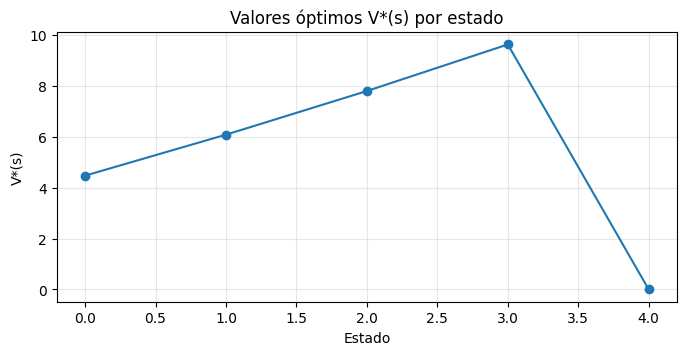

In [9]:
plt.figure(figsize=(8, 3.5))
plt.plot(states, [V_opt[s] for s in states], marker="o")
plt.title("Valores óptimos V*(s) por estado")
plt.xlabel("Estado")
plt.ylabel("V*(s)")
plt.grid(True, alpha=0.3)
plt.show()


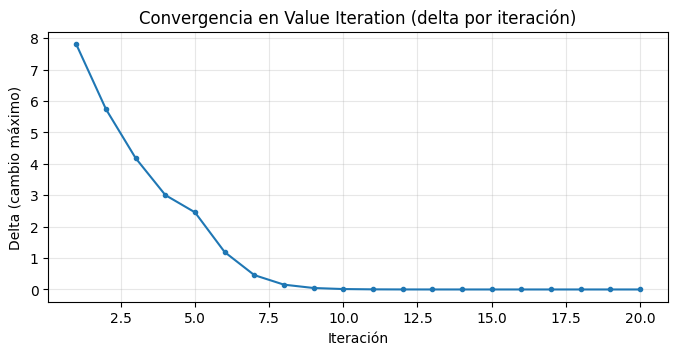

In [10]:
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, len(deltas) + 1), deltas, marker="o", markersize=3)
plt.title("Convergencia en Value Iteration (delta por iteración)")
plt.xlabel("Iteración")
plt.ylabel("Delta (cambio máximo)")
plt.grid(True, alpha=0.3)
plt.show()


In [11]:
def optimal_policy(s):
    return "RIGHT" if s == terminal_state else pi_opt[s]

mean_opt, std_opt = evaluate_policy(optimal_policy, gamma=gamma)

pd.DataFrame({
    "política": ["aleatoria", "siempre RIGHT", "óptima (Value Iteration)"],
    "retorno_promedio": [mean_rnd, mean_right, mean_opt],
    "desv_std": [std_rnd, std_right, std_opt]
})


,política,retorno_promedio,desv_std
0,aleatoria,-7.528516,7.366437
1,siempre RIGHT,4.462648,1.346099
2,óptima (Value Iteration),4.384493,1.371507
